# Ejercicio 1.

#### Encuentre todos los puntos críticos de la siguiente función y clasifíquelos como máximo local, mínimo local o punto de silla, utilizando el método gráfico y las condiciones de optimalidad de primer y segundo orden.

$$f(x,y) = x^3 + y^3 - 3xy$$

C:\Users\raalv\AppData\Local\Temp\ipykernel_18864\3356306536.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
C:\Users\raalv\AppData\Local\Temp\ipykernel_18864\3356306536.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


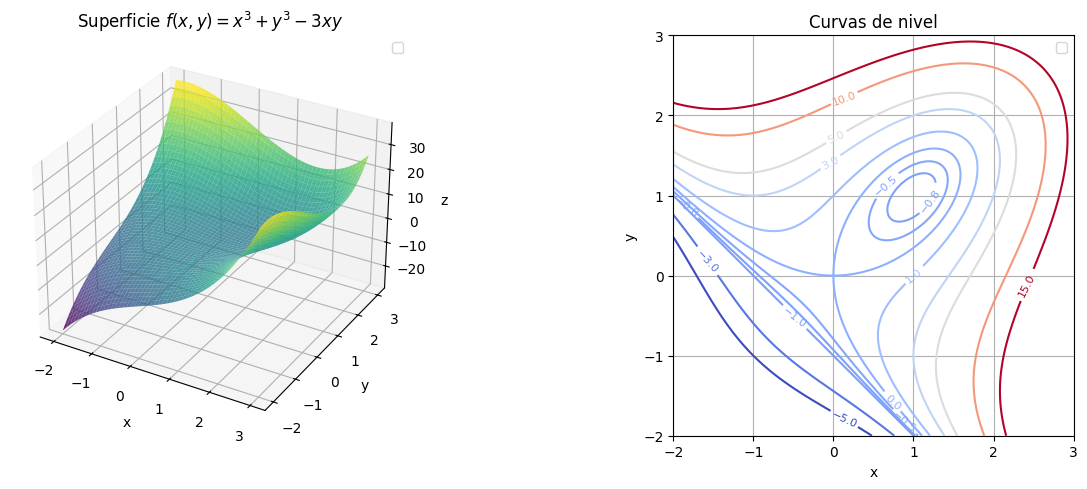

In [2]:
import numpy as np
import matplotlib.pyplot as plt

f = lambda x, y: x**3 + y**3 - 3*x*y

x = np.linspace(-2, 3, 200)
y = np.linspace(-2, 3, 200)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

# Gráfico 3D
fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.8)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')
ax1.set_title('Superficie $f(x,y) = x^3 + y^3 - 3xy$')
ax1.legend()

# Curvas de nivel
ax2 = fig.add_subplot(122)
contours = ax2.contour(X, Y, Z, levels=[-5, -3, -1, -0.8, -0.5, 0, 1, 3, 5, 10, 15], cmap='coolwarm')
ax2.clabel(contours, inline=True, fontsize=8)

ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Curvas de nivel')
ax2.grid(True)
ax2.legend()
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

In [ ]:
from scipy.optimize import minimize
import numpy as np

def funcion_objetivo(x):
    return x[0]**3 + x[1]**3 - 3*x[0]*x[1]

# Buscar mínimo local partiendo cerca de (1,1)
x0 = np.array([0.5, 0.5])
result = minimize(funcion_objetivo, x0)
print("Mínimo local encontrado:")
print(f"\nPunto: ({result.x[0]:.4f}, {result.x[1]:.4f})")
print(f"Valor: {result.fun:.4f}")

# Ejercicio 2

#### Se le entrega el siguiente problema de optimización con restricción de igualdad. Resuelva mediante multiplicadores de Lagrange.

### Objetivo:

$$
\min f(x, y) = x^2 + 2y^2 + xy
$$

### Sujeto a:

$$x + y = 12$$
$$x \geq 0$$
$$y \geq 0$$

Para un mejor entendimiento:

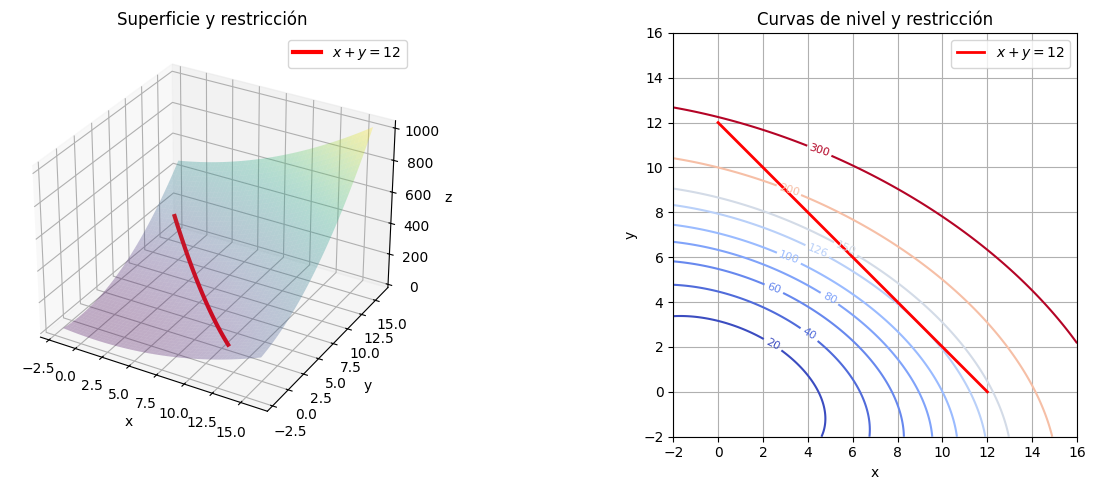

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Función objetivo
def fobj(x, y):
    return x**2 + 2*y**2 + x*y

# Restricción: x + y = 12
def g(x, y):
    return x + y - 12

x = np.linspace(-2, 16, 200)
y = np.linspace(-2, 16, 200)
X, Y = np.meshgrid(x, y)
Z = fobj(X, Y)

fig = plt.figure(figsize=(14, 5))

# Gráfico 3D
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.3, edgecolor='none')
# Dibujar la restricción como una curva sobre la superficie
x_rest = np.linspace(0, 12, 100)
y_rest = 12 - x_rest
z_rest = fobj(x_rest, y_rest)
ax1.plot(x_rest, y_rest, z_rest, 'r-', linewidth=3, label='$x + y = 12$')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')
ax1.set_title('Superficie y restricción')
ax1.legend()

# Curvas de nivel con restricción
ax2 = fig.add_subplot(122)
contours = ax2.contour(X, Y, Z, levels=[20, 40, 60, 80, 100, 126, 150, 200, 300], cmap='coolwarm')
ax2.clabel(contours, inline=True, fontsize=8)
ax2.plot(x_rest, y_rest, 'r-', linewidth=2, label='$x + y = 12$')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Curvas de nivel y restricción')
ax2.set_xlim(-2, 16)
ax2.set_ylim(-2, 16)
ax2.grid(True)
ax2.legend()
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

In [ ]:
from scipy.optimize import minimize
import numpy as np

fo = lambda x: x[0]**2 + 2*x[1]**2 + x[0]*x[1]
restriccion = lambda x: x[0] + x[1] - 12

x0 = np.array([6, 6])
constraints = [{'type': 'eq', 'fun': restriccion}]

noneg = [(0, np.inf), (0, np.inf)]

res = minimize(fo, x0, method='SLSQP', constraints=constraints, bounds=noneg)

print(f"\nPunto óptimo: x = {res.x[0]:.4f}, y = {res.x[1]:.4f}")
print(f"Valor óptimo: {res.fun:.4f}")

# Ejercicio 3.
#### Resuelva la misma función del ejercicio 2, con Gurobi.

In [ ]:
import gurobipy as gp
from gurobipy import GRB

# Ejercicio 4.

#### Se le entrega el siguiente problema de optimización con restricciones de desigualdad. Resuelva mediante el método de KKT.

### Objetivo:

$$
\min f(x, y) = (x - 3)^2 + (y - 2)^2
$$

### Sujeto a:

\begin{cases}
g_1(x, y) = x^2 + y^2 - 5 \leq 0\\
g_2(x, y) = x + 2y - 4 \leq 0\\
g_3(x) = x \geq 0\\
g_4(y) = y \geq 0
\end{cases}

Para un mejor entendimiento:

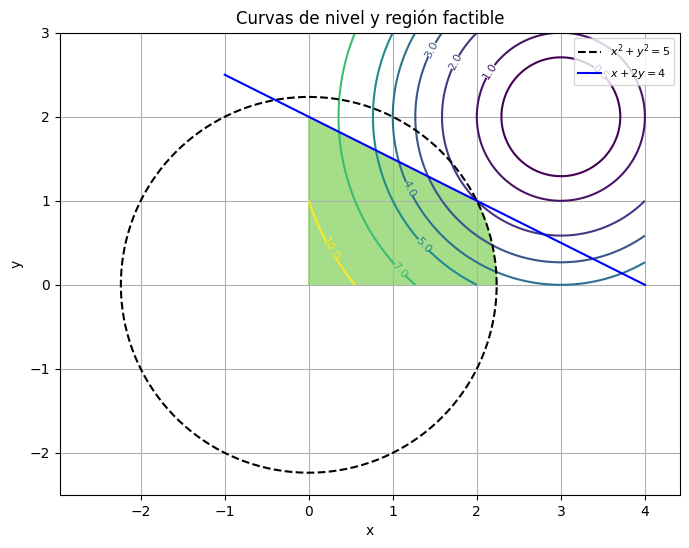

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Crear malla
x = np.linspace(0, 4, 400)
y = np.linspace(0, 3, 400)
X, Y = np.meshgrid(x, y)

# Función objetivo
Z = (X - 3)**2 + (Y - 2)**2

# Restricciones
g1 = X**2 + Y**2 <= 5
g2 = X + 2*Y <= 4
g3 = (X >= 0) & (Y >= 0)
factible = g1 & g2 & g3

# Crear figura
plt.figure(figsize=(8, 6))

# Dibujar curvas de nivel
contours = plt.contour(X, Y, Z, levels=[0.5, 1, 2, 3, 4, 5, 7, 10], cmap='viridis')
plt.clabel(contours, inline=True, fontsize=8)

# Sombrear región factible
plt.contourf(X, Y, factible.astype(float), levels=[0.5, 1], colors=["#4dbc15"], alpha=0.5)

# Dibujar fronteras
theta = np.linspace(0, 2*np.pi, 300)
plt.plot(np.sqrt(5)*np.cos(theta), np.sqrt(5)*np.sin(theta), 'k--', label='$x^2 + y^2 = 5$')
x_line = np.linspace(-1, 4, 100)
plt.plot(x_line, (4 - x_line)/2, 'b-', label='$x + 2y = 4$')

# Configurar gráfica
plt.xlabel('x')
plt.ylabel('y')
plt.title('Curvas de nivel y región factible')
plt.xlim(0, 4)
plt.ylim(0, 3)
plt.grid(True)
plt.legend(loc='upper right', fontsize=8)
plt.axis('equal')

plt.show()

In [ ]:
from scipy.optimize import minimize
import numpy as np

fo = lambda x: (x[0] - 3)**2 + (x[1] - 2)**2
r1 = lambda x: -(x[0]**2 + x[1]**2 - 5)   # g1 <= 0 → -g1 >= 0
r2 = lambda x: -(x[0] + 2*x[1] - 4)        # g2 <= 0 → -g2 >= 0

x0 = np.array([1.0, 1.0])
constraints = [{'type': 'ineq', 'fun': r1}, {'type': 'ineq', 'fun': r2}]
noneg = [(0, np.inf), (0, np.inf)]

res = minimize(fo, x0, method='SLSQP', constraints=constraints, bounds=noneg)
print(res)
print(f"\nPunto óptimo: x = {res.x[0]:.4f}, y = {res.x[1]:.4f}")
print(f"Valor óptimo: {res.fun:.4f}")

# Ejercicio 5.

#### Considere la función de Himmelblau, que posee múltiples mínimos locales. Utilice el método del gradiente descendente con paso fijo y con dirección normalizada para aproximar un mínimo local.

$$f(x, y) = (x^2 + y - 11)^2 + (x + y^2 - 7)^2$$

Esta función tiene 4 mínimos locales (todos con $f \approx 0$). Dependiendo del punto inicial, el gradiente descendente convergirá a un mínimo distinto.

**Gradiente analítico:**
$$\frac{\partial f}{\partial x} = 4x(x^2 + y - 11) + 2(x + y^2 - 7)$$
$$\frac{\partial f}{\partial y} = 2(x^2 + y - 11) + 4y(x + y^2 - 7)$$

**Recordatorio:**

**Gradiente descendente con paso fijo:**
$$\vec{x}_{i+1} = \vec{x}_i - \alpha \nabla f(\vec{x}_i)$$

**Gradiente descendente con dirección normalizada:**
$$\vec{x}_{i+1} = \vec{x}_i - \alpha \frac{\nabla f(\vec{x}_i)}{||\nabla f(\vec{x}_i)||}$$

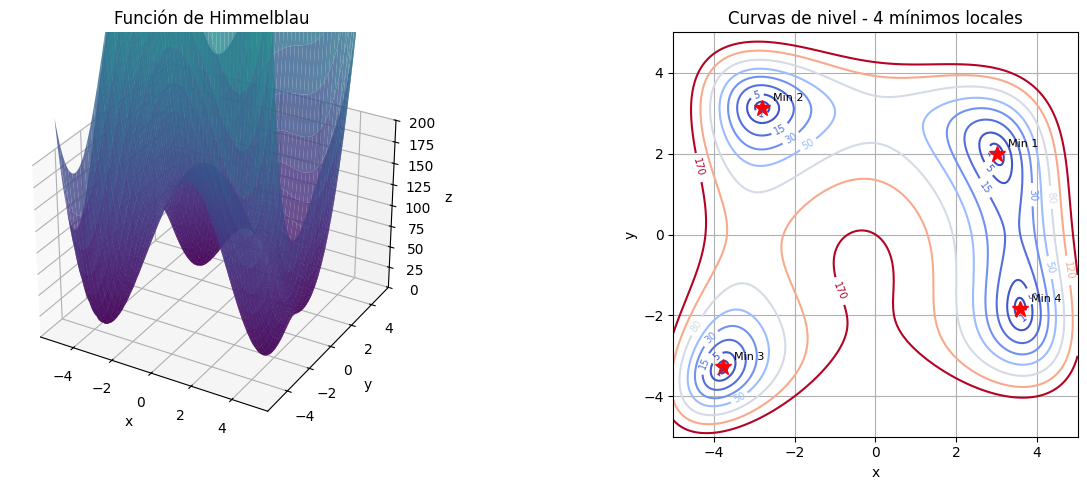

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Función de Himmelblau
def f(x, y):
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

# Gradiente analítico
def grad_f(x, y):
    df_dx = 4*x*(x**2 + y - 11) + 2*(x + y**2 - 7)
    df_dy = 2*(x**2 + y - 11) + 4*y*(x + y**2 - 7)
    return np.array([df_dx, df_dy])

# Visualizar la función
x = np.linspace(-5, 5, 300)
y = np.linspace(-5, 5, 300)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.8)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')
ax1.set_zlim(0, 200)
ax1.set_title('Función de Himmelblau')

# Curvas de nivel + marcar los 4 mínimos
ax2 = fig.add_subplot(122)
contours = ax2.contour(X, Y, Z, levels=[1, 5, 15, 30, 50, 80, 120, 170], cmap='coolwarm')
ax2.clabel(contours, inline=True, fontsize=7)
minimos = [(3, 2), (-2.805, 3.131), (-3.779, -3.283), (3.584, -1.848)]
for i, (mx, my) in enumerate(minimos):
    ax2.plot(mx, my, 'r*', markersize=12)
    ax2.annotate(f'Min {i+1}', (mx, my), textcoords='offset points', xytext=(8, 5), fontsize=8)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Curvas de nivel - 4 mínimos locales')
ax2.grid(True)
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

### a) Gradiente descendente con paso fijo

Inicio (-2, 4.5) → Mínimo (-2.8027, 3.1312), f = 0.000185, Iters: 13
Inicio (1, 4) → Mínimo (2.9979, 2.0051), f = 0.000398, Iters: 36
Inicio (-4, -1) → Mínimo (-3.7786, -3.2820), f = 0.000072, Iters: 18
Inicio (4, -3) → Mínimo (3.5849, -1.8535), f = 0.000426, Iters: 24


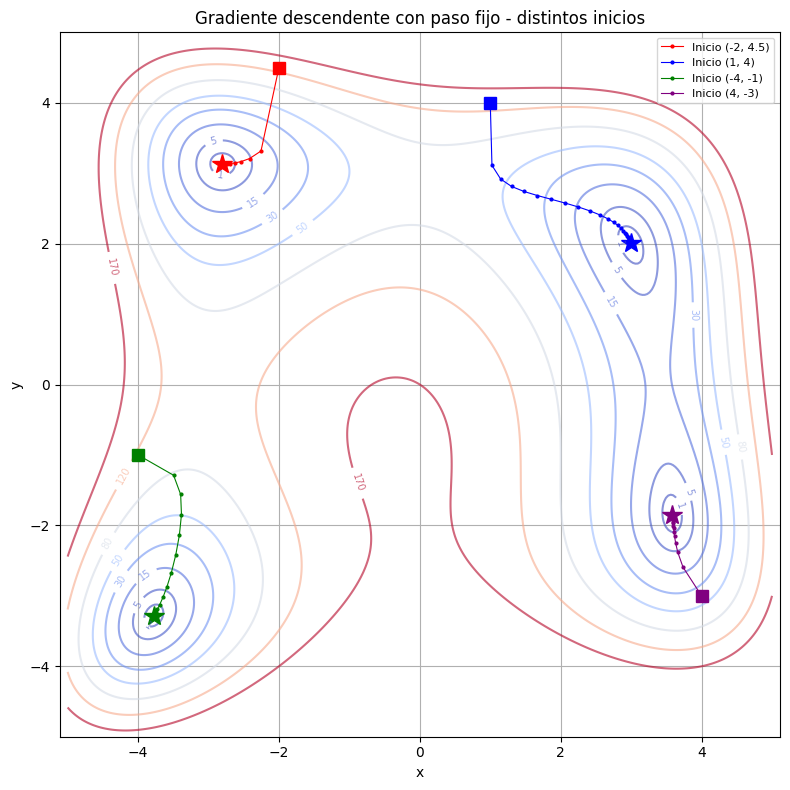

In [5]:
# Gradiente descendente con paso fijo - probar distintos puntos iniciales
puntos_iniciales = [(-2, 4.5), (1, 4), (-4, -1), (4, -3)]

resultados_fijo = []

def f(x, y):
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

# Gradiente analítico
def grad_f(x, y):
    df_dx = 4*x*(x**2 + y - 11) + 2*(x + y**2 - 7)
    df_dy = 2*(x**2 + y - 11) + 4*y*(x + y**2 - 7)
    return np.array([df_dx, df_dy])
punto_inicial = (1,4)

histx = [punto_inicial[0]]
histy = [punto_inicial[1]]
alpha = 0.006
tol =  1e-3
it = 100

#### CÓDIGO AQUÍ ####
for x0, y0 in puntos_iniciales:
    x_hist = [x0]
    y_hist = [y0]
    xk, yk = x0, y0
    
    for i in range(it):
        grad = grad_f(xk, yk)
        xk_new = xk - alpha * grad[0]
        yk_new = yk - alpha * grad[1]
        
        if np.linalg.norm([xk_new - xk, yk_new - yk]) < tol:
            break
        
        xk, yk = xk_new, yk_new
        x_hist.append(xk)
        y_hist.append(yk)
    
    resultados_fijo.append((x_hist, y_hist))
    print(f"Inicio ({x0}, {y0}) → Mínimo ({xk:.4f}, {yk:.4f}), f = {f(xk, yk):.6f}, Iters: {len(x_hist)-1}")


#####################

# Visualizar trayectorias
colores = ['red', 'blue', 'green', 'purple']
plt.figure(figsize=(8, 8))
contours = plt.contour(X, Y, Z, levels=[1, 5, 15, 30, 50, 80, 120, 170], cmap='coolwarm', alpha=0.6)
plt.clabel(contours, inline=True, fontsize=7)

for idx, ((x_hist, y_hist), (x0, y0)) in enumerate(zip(resultados_fijo, puntos_iniciales)):
    plt.plot(x_hist, y_hist, 'o-', color=colores[idx], markersize=2, linewidth=0.8, 
             label=f'Inicio ({x0}, {y0})')
    plt.plot(x_hist[0], y_hist[0], 's', color=colores[idx], markersize=8)
    plt.plot(x_hist[-1], y_hist[-1], '*', color=colores[idx], markersize=15)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Gradiente descendente con paso fijo - distintos inicios')
plt.legend(fontsize=8)
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.show()

### b) Gradiente descendente con dirección normalizada

In [ ]:
# Gradiente descendente con dirección normalizada - mismos puntos iniciales
puntos_iniciales = [(-2, 4.5), (1, 4), (-4, -1), (4, -3)]

resultados_norm = []

#### CÓDIGO AQUÍ ####




#####################

colores = ['red', 'blue', 'green', 'purple']
plt.figure(figsize=(8, 8))
contours = plt.contour(X, Y, Z, levels=[1, 5, 15, 30, 50, 80, 120, 170], cmap='coolwarm', alpha=0.6)
plt.clabel(contours, inline=True, fontsize=7)

for idx, ((x_hist, y_hist), (x0, y0)) in enumerate(zip(resultados_norm, puntos_iniciales)):
    plt.plot(x_hist, y_hist, 'o-', color=colores[idx], markersize=2, linewidth=0.8,
            label=f'Inicio ({x0}, {y0})')
    plt.plot(x_hist[0], y_hist[0], 's', color=colores[idx], markersize=8)
    plt.plot(x_hist[-1], y_hist[-1], '*', color=colores[idx], markersize=15)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Gradiente con Dirección Normalizada - distintos inicios')
plt.legend(fontsize=8)
plt.grid(True)

In [ ]:
# Comparar paso fijo vs normalizado para un mismo punto inicial
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, resultados, titulo in zip(axes, [resultados_fijo, resultados_norm], 
                                     ['Paso fijo ($\\alpha = 0.005$)', 'Dirección normalizada ($\\alpha = 0.05$)']):
    contours = ax.contour(X, Y, Z, levels=[1, 5, 15, 30, 50, 80, 120, 170], cmap='coolwarm', alpha=0.6)
    ax.clabel(contours, inline=True, fontsize=7)
    
    for idx, ((x_hist, y_hist), (x0, y0)) in enumerate(zip(resultados, puntos_iniciales)):
        ax.plot(x_hist, y_hist, 'o-', color=colores[idx], markersize=2, linewidth=0.8,
                label=f'Inicio ({x0}, {y0})')
        ax.plot(x_hist[0], y_hist[0], 's', color=colores[idx], markersize=8)
        ax.plot(x_hist[-1], y_hist[-1], '*', color=colores[idx], markersize=15)
    
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(titulo)
    ax.legend(fontsize=8)
    ax.grid(True)
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()